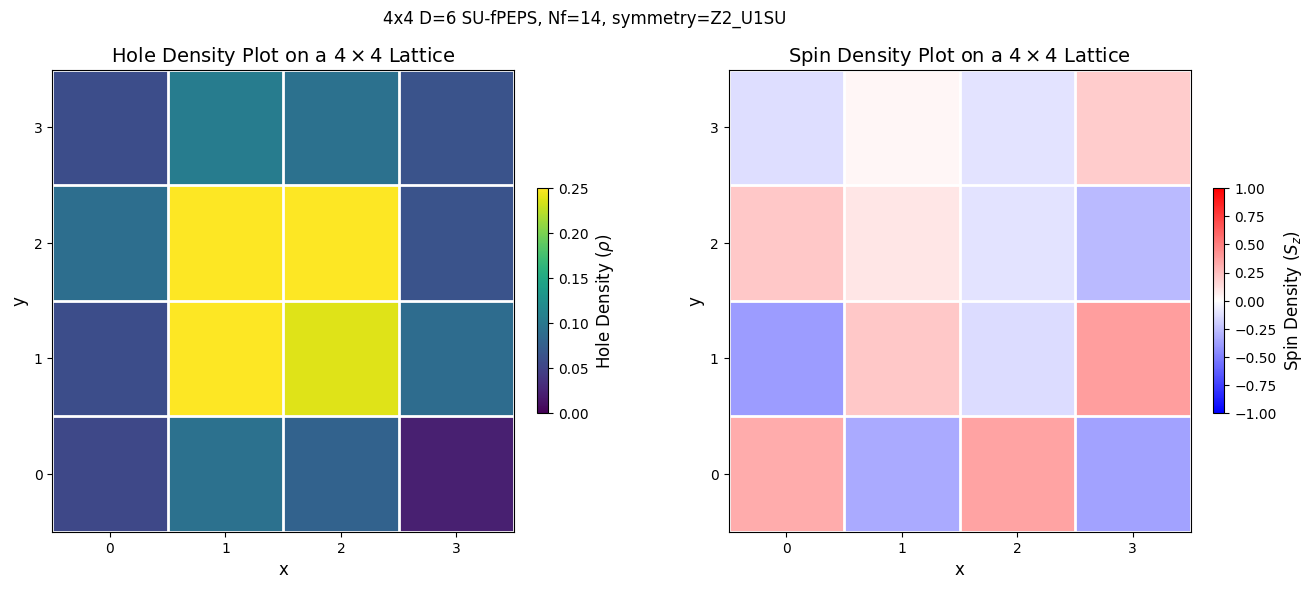

6.938893903907228e-18 0.125
Min hole density: 0.022058823529411766, Max hole density: 0.3088235294117647
Min spin density: -0.3872549019607843, Max spin density: 0.38235294117647056


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from vmc_torch.experiment.tn_model import fTNModel_reuse
pwd = '/home/sijingdu/TNVMC/VMC_code/vmc_torch/scripts/4x4/test_data'
# Hamiltonian parameters
Lx = int(4)
Ly = int(4)
symmetry = 'U1SU'
appendix = ''
if symmetry == 'U1SU':
    symmetry = 'Z2'
    appendix = '_U1SU'
t = 1.0
U = 8.0
N_f = int(Lx*Ly-2)
n_fermions_per_spin = (N_f//2, N_f//2)
# TN parameters
D = 6
chi = 4*D
model_names = {
    fTNModel_reuse: 'fTN_reuse'+appendix,
}
model_name = model_names[fTNModel_reuse]
configs = np.load(pwd+f'/{Lx}x{Ly}/t={t}_U={U}/N={N_f}/{symmetry}/D={D}/{model_name}/chi={chi}/sampled_configs.npy')

def charge_map(config):
    mapping = {0:0, 1:1, 2:1, 3:2}
    return np.vectorize(mapping.get)(config)

def hole_map(config):
    mapping = {0:1, 1:0, 2:0, 3:-1}
    return np.vectorize(mapping.get)(config)

def spin_map(config):
    mapping = {0:0, 1:-1, 2:1, 3:0}
    return np.vectorize(mapping.get)(config)

# charge_configs = charge_map(configs)
charge_configs = hole_map(configs)
spin_configs = spin_map(configs)

avg_charge_config = np.mean(charge_configs, axis=0)
avg_spin_config = np.mean(spin_configs, axis=0)

# reshape to 2D lattice
avg_charge_config_2d = avg_charge_config.reshape((Lx, Ly))
avg_spin_config_2d = avg_spin_config.reshape((Lx, Ly))

# 3. Create the heatmap plot
fig, ax = plt.subplots(1, 2, figsize=(16, 6))
im = ax[0].imshow(avg_charge_config_2d, cmap='viridis', aspect='equal', origin='lower', vmin=0, vmax=0.25)

# 4. Add a colorbar and labels to the first plot
cbar = fig.colorbar(im, ax=ax[0], orientation='vertical', fraction=0.02, pad=0.04)
# Use raw string 'r' for LaTeX in the label
cbar.set_label(r'Hole Density ($\rho$)', fontsize=12)

# Set title and labels, using raw string 'r' for LaTeX
ax[0].set_title(rf'Hole Density Plot on a ${Lx} \times {Ly}$ Lattice', fontsize=14)
ax[0].set_xlabel('x', fontsize=12)
ax[0].set_ylabel('y', fontsize=12)

# Set ticks to represent the lattice sites, centered on the cells
ax[0].set_xticks(np.arange(Ly))
ax[0].set_yticks(np.arange(Lx))

# Add a grid to delineate the cells clearly
ax[0].set_xticks(np.arange(Ly+1)-0.5, minor=True)
ax[0].set_yticks(np.arange(Lx+1)-0.5, minor=True)
ax[0].grid(which="minor", color="w", linestyle='-', linewidth=2)
ax[0].tick_params(which="minor", bottom=False, left=False)


im2 = ax[1].imshow(avg_spin_config_2d, cmap='bwr', aspect='equal', origin='lower', vmin=-1, vmax=1)
# 4. Add a colorbar and labels
cbar2 = fig.colorbar(im2, ax=ax[1], orientation='vertical',
                        fraction=0.02, pad=0.04)    
# Use raw string 'r' for LaTeX in the label
cbar2.set_label(r'Spin Density ($S_z$)', fontsize=12)
# Set title and labels, using raw string 'r' for LaTeX
ax[1].set_title(rf'Spin Density Plot on a ${Lx} \times {Ly}$ Lattice', fontsize=14)
ax[1].set_xlabel('x', fontsize=12)
ax[1].set_ylabel('y', fontsize=12)
# Set ticks to represent the lattice sites, centered on the cells
ax[1].set_xticks(np.arange(Ly))
ax[1].set_yticks(np.arange(Lx))
# Add a grid to delineate the cells clearly
ax[1].set_xticks(np.arange(Ly+1)-0.5, minor=True)
ax[1].set_yticks(np.arange(Lx+1)-0.5, minor=True)
ax[1].grid(which="minor", color="w", linestyle='-', linewidth=2)
ax[1].tick_params(which="minor", bottom=False, left=False)  
plt.suptitle(f'{Lx}x{Ly} D={D} SU-fPEPS, Nf={N_f}, symmetry={symmetry}{appendix}')
plt.show()
print(avg_spin_config_2d.sum()/(Lx*Ly), avg_charge_config_2d.sum()/(Lx*Ly))
print(f'Min hole density: {avg_charge_config_2d.min()}, Max hole density: {avg_charge_config_2d.max()}')
print(f'Min spin density: {avg_spin_config_2d.min()}, Max spin density: {avg_spin_config_2d.max()}')

In [1]:
import symmray as sr
import quimb.tensor as qtn
from vmc_torch.fermion_utils import generate_random_fpeps_symmray

Lx, Ly = 4, 16
edges = qtn.edges_2d_square(Lx, Ly)
D=8
site_info = sr.parse_edges_to_site_info(
    edges,
    D,
    phys_dim=4,
    site_ind_id="k{},{}",
    site_tag_id="I{},{}",
)
u1_terms = {
    (sitea, siteb): sr.fermi_hubbard_local_array(
        t=1,
        U=8,
        mu=0.0,
        symmetry="U1",
        coordinations=(
            site_info[sitea]["coordination"],
            site_info[siteb]["coordination"],
        ),
    )
    for (sitea, siteb) in edges
}

u1ham = qtn.LocalHam2D(Lx, Ly, H2=u1_terms)
# fpeps = sr.PEPS_fermionic_rand(
#     "U1",
#     Lx,
#     Ly,
#     bond_dim=D,
#     phys_dim=4
# )
fpeps = generate_random_fpeps_symmray(
    Lx,
    Ly,
    D=D,
    seed=42,
    symmetry="U1",
    Nf=Lx*Ly-8,
    spinless=False,
)
u1su = qtn.SimpleUpdateGen(
        fpeps, 
        u1ham, 
        D=D, 
        equilibrate_start=False
)
u1su.evolve(10, tau=0.01)

n=3, D=8, tau=0.01, max|dS|=0.0204:  30%|###       | 3/10 [00:14<00:34,  4.95s/it]


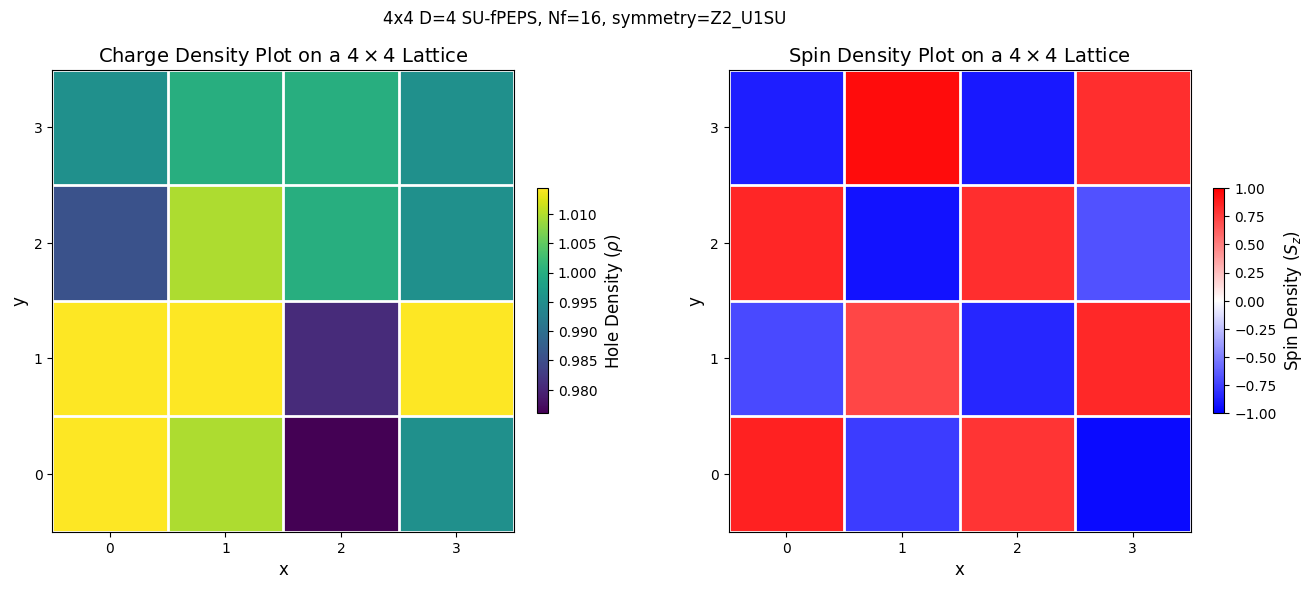

-2.220446049250313e-16 16.0
0.9519230769230769 -0.9567307692307693


In [21]:
import numpy as np
import matplotlib.pyplot as plt
from vmc_torch.experiment.tn_model import fTNModel_reuse
pwd = '/home/sijingdu/TNVMC/VMC_code/vmc_torch/scripts/4x4/test_data'
# Hamiltonian parameters
Lx = int(4)
Ly = int(4)
symmetry = 'U1SU'
appendix = ''
if symmetry == 'U1SU':
    symmetry = 'Z2'
    appendix = '_U1SU'
t = 1.0
U = 8.0
N_f = int(Lx*Ly)
n_fermions_per_spin = (N_f//2, N_f//2)
# TN parameters
D = 4
chi = 4*D
model_names = {
    fTNModel_reuse: 'fTN_reuse'+appendix,
}
model_name = model_names[fTNModel_reuse]
configs = np.load(pwd+f'/{Lx}x{Ly}/t={t}_U={U}/N={N_f}/{symmetry}/D={D}/{model_name}/chi={chi}/sampled_configs.npy')

def charge_map(config):
    mapping = {0:0, 1:1, 2:1, 3:2}
    return np.vectorize(mapping.get)(config)

def spin_map(config):
    mapping = {0:0, 1:-1, 2:1, 3:0}
    return np.vectorize(mapping.get)(config)

charge_configs = charge_map(configs)
spin_configs = spin_map(configs)

avg_charge_config = np.mean(charge_configs, axis=0)
avg_spin_config = np.mean(spin_configs, axis=0)

# reshape to 2D lattice
avg_charge_config_2d = avg_charge_config.reshape((Lx, Ly))
avg_spin_config_2d = avg_spin_config.reshape((Lx, Ly))

# 3. Create the heatmap plot
fig, ax = plt.subplots(1, 2, figsize=(16, 6))
im = ax[0].imshow(avg_charge_config_2d, cmap='viridis', aspect='equal', origin='lower')

# 4. Add a colorbar and labels to the first plot
cbar = fig.colorbar(im, ax=ax[0], orientation='vertical', fraction=0.02, pad=0.04)
# Use raw string 'r' for LaTeX in the label
cbar.set_label(r'Hole Density ($\rho$)', fontsize=12)

# Set title and labels, using raw string 'r' for LaTeX
ax[0].set_title(rf'Charge Density Plot on a ${Lx} \times {Ly}$ Lattice', fontsize=14)
ax[0].set_xlabel('x', fontsize=12)
ax[0].set_ylabel('y', fontsize=12)

# Set ticks to represent the lattice sites, centered on the cells
ax[0].set_xticks(np.arange(Ly))
ax[0].set_yticks(np.arange(Lx))

# Add a grid to delineate the cells clearly
ax[0].set_xticks(np.arange(Ly+1)-0.5, minor=True)
ax[0].set_yticks(np.arange(Lx+1)-0.5, minor=True)
ax[0].grid(which="minor", color="w", linestyle='-', linewidth=2)
ax[0].tick_params(which="minor", bottom=False, left=False)


im2 = ax[1].imshow(avg_spin_config_2d, cmap='bwr', aspect='equal', origin='lower', vmin=-1, vmax=1)
# 4. Add a colorbar and labels
cbar2 = fig.colorbar(im2, ax=ax[1], orientation='vertical',
                        fraction=0.02, pad=0.04)    
# Use raw string 'r' for LaTeX in the label
cbar2.set_label(r'Spin Density ($S_z$)', fontsize=12)
# Set title and labels, using raw string 'r' for LaTeX
ax[1].set_title(rf'Spin Density Plot on a ${Lx} \times {Ly}$ Lattice', fontsize=14)
ax[1].set_xlabel('x', fontsize=12)
ax[1].set_ylabel('y', fontsize=12)
# Set ticks to represent the lattice sites, centered on the cells
ax[1].set_xticks(np.arange(Ly))
ax[1].set_yticks(np.arange(Lx))
# Add a grid to delineate the cells clearly
ax[1].set_xticks(np.arange(Ly+1)-0.5, minor=True)
ax[1].set_yticks(np.arange(Lx+1)-0.5, minor=True)
ax[1].grid(which="minor", color="w", linestyle='-', linewidth=2)
ax[1].tick_params(which="minor", bottom=False, left=False)  
plt.suptitle(f'{Lx}x{Ly} D={D} SU-fPEPS, Nf={N_f}, symmetry={symmetry}{appendix}')
plt.show()
print(avg_spin_config_2d.sum(), avg_charge_config_2d.sum())
print(avg_spin_config_2d.max(), avg_spin_config_2d.min())

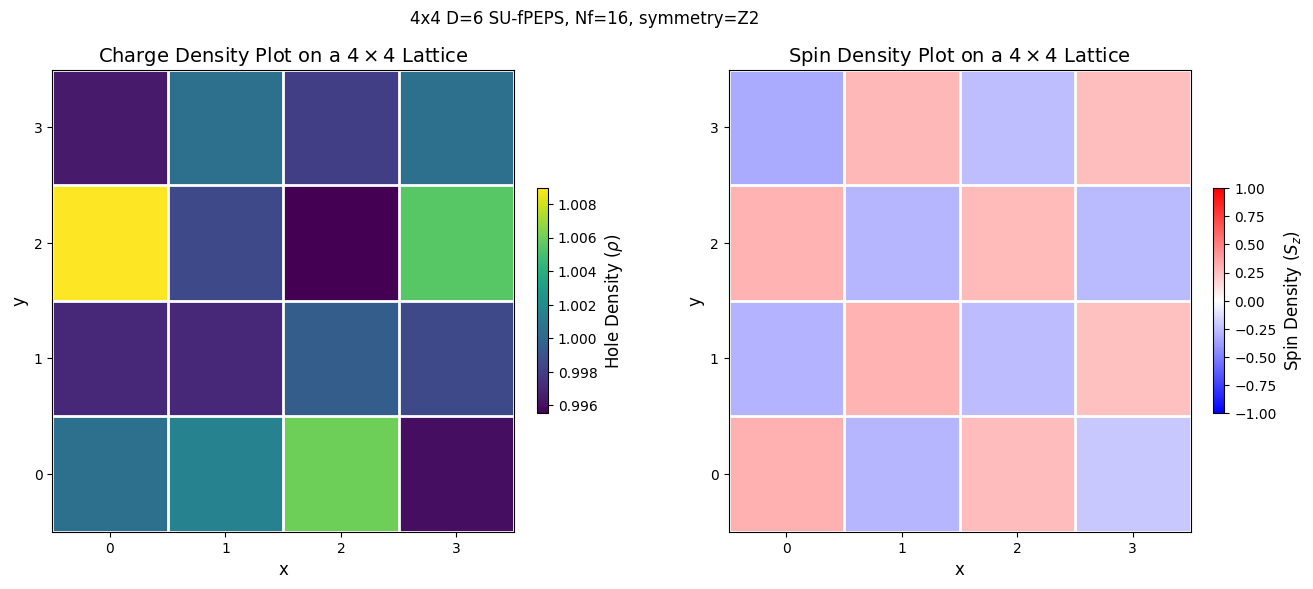

0.0 16.0


In [12]:
import numpy as np
import matplotlib.pyplot as plt
from vmc_torch.experiment.tn_model import fTNModel_reuse
pwd = '/home/sijingdu/TNVMC/VMC_code/vmc_torch/data'
# Hamiltonian parameters
Lx = int(4)
Ly = int(4)
symmetry = 'Z2'
appendix = ''
if symmetry == 'U1SU':
    symmetry = 'Z2'
    appendix = '_U1SU'
t = 1.0
U = 8.0
N_f = int(Lx*Ly)
n_fermions_per_spin = (N_f//2, N_f//2)
# TN parameters
D = 6
chi = 24
model_names = {
    fTNModel_reuse: 'fTN_reuse'+appendix,
}
model_name = model_names[fTNModel_reuse]
configs = np.load(pwd+f'/{Lx}x{Ly}/t={t}_U={U}/N={N_f}/{symmetry}/D={D}/{model_name}/chi={chi}/sampled_configs.npy')

def charge_map(config):
    mapping = {0:0, 1:1, 2:1, 3:2}
    return np.vectorize(mapping.get)(config)

def spin_map(config):
    mapping = {0:0, 1:-1, 2:1, 3:0}
    return np.vectorize(mapping.get)(config)

charge_configs = charge_map(configs)
spin_configs = spin_map(configs)

avg_charge_config = np.mean(charge_configs, axis=0)
avg_spin_config = np.mean(spin_configs, axis=0)

# reshape to 2D lattice
avg_charge_config_2d = avg_charge_config.reshape((Lx, Ly))
avg_spin_config_2d = avg_spin_config.reshape((Lx, Ly))

# 3. Create the heatmap plot
fig, ax = plt.subplots(1, 2, figsize=(16, 6))
im = ax[0].imshow(avg_charge_config_2d, cmap='viridis', aspect='equal', origin='lower')

# 4. Add a colorbar and labels to the first plot
cbar = fig.colorbar(im, ax=ax[0], orientation='vertical', fraction=0.02, pad=0.04)
# Use raw string 'r' for LaTeX in the label
cbar.set_label(r'Hole Density ($\rho$)', fontsize=12)

# Set title and labels, using raw string 'r' for LaTeX
ax[0].set_title(rf'Charge Density Plot on a ${Lx} \times {Ly}$ Lattice', fontsize=14)
ax[0].set_xlabel('x', fontsize=12)
ax[0].set_ylabel('y', fontsize=12)

# Set ticks to represent the lattice sites, centered on the cells
ax[0].set_xticks(np.arange(Ly))
ax[0].set_yticks(np.arange(Lx))

# Add a grid to delineate the cells clearly
ax[0].set_xticks(np.arange(Ly+1)-0.5, minor=True)
ax[0].set_yticks(np.arange(Lx+1)-0.5, minor=True)
ax[0].grid(which="minor", color="w", linestyle='-', linewidth=2)
ax[0].tick_params(which="minor", bottom=False, left=False)


im2 = ax[1].imshow(avg_spin_config_2d, cmap='bwr', aspect='equal', origin='lower', vmin=-1, vmax=1)
# 4. Add a colorbar and labels
cbar2 = fig.colorbar(im2, ax=ax[1], orientation='vertical',
                        fraction=0.02, pad=0.04)    
# Use raw string 'r' for LaTeX in the label
cbar2.set_label(r'Spin Density ($S_z$)', fontsize=12)
# Set title and labels, using raw string 'r' for LaTeX
ax[1].set_title(rf'Spin Density Plot on a ${Lx} \times {Ly}$ Lattice', fontsize=14)
ax[1].set_xlabel('x', fontsize=12)
ax[1].set_ylabel('y', fontsize=12)
# Set ticks to represent the lattice sites, centered on the cells
ax[1].set_xticks(np.arange(Ly))
ax[1].set_yticks(np.arange(Lx))
# Add a grid to delineate the cells clearly
ax[1].set_xticks(np.arange(Ly+1)-0.5, minor=True)
ax[1].set_yticks(np.arange(Lx+1)-0.5, minor=True)
ax[1].grid(which="minor", color="w", linestyle='-', linewidth=2)
ax[1].tick_params(which="minor", bottom=False, left=False)  
plt.suptitle(f'{Lx}x{Ly} D={D} SU-fPEPS, Nf={N_f}, symmetry={symmetry}{appendix}')
plt.show()
print(avg_spin_config_2d.sum(), avg_charge_config_2d.sum())

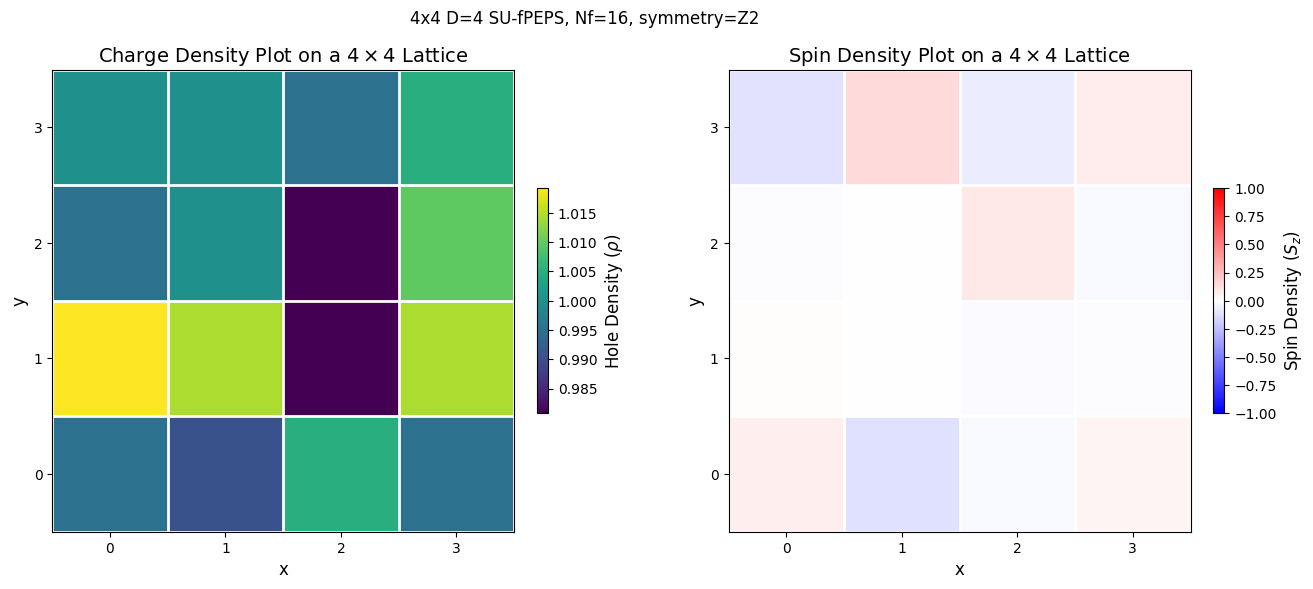

-4.163336342344337e-17 16.0


In [16]:
import numpy as np
import matplotlib.pyplot as plt
from vmc_torch.experiment.tn_model import fTNModel_reuse, fTN_backflow_attn_Tensorwise_Model_v1
pwd = '/home/sijingdu/TNVMC/VMC_code/vmc_torch/data'
# Hamiltonian parameters
Lx = int(4)
Ly = int(4)
symmetry = 'Z2'
appendix = ''
if symmetry == 'U1SU':
    symmetry = 'Z2'
    appendix = '_U1SU'
t = 1.0
U = 8.0
N_f = int(Lx*Ly)
n_fermions_per_spin = (N_f//2, N_f//2)
# TN parameters
D = 4
chi = -2
model_names = {
    fTNModel_reuse: 'fTN_reuse'+appendix,
    fTN_backflow_attn_Tensorwise_Model_v1: f'fTN_backflow_attn_Tensorwise_v1{appendix}',
}
model_name = model_names[fTN_backflow_attn_Tensorwise_Model_v1]
configs = np.load(pwd+f'/{Lx}x{Ly}/t={t}_U={U}/N={N_f}/{symmetry}/D={D}/{model_name}/chi={chi}/sampled_configs.npy')

def charge_map(config):
    mapping = {0:0, 1:1, 2:1, 3:2}
    return np.vectorize(mapping.get)(config)

def spin_map(config):
    mapping = {0:0, 1:-1, 2:1, 3:0}
    return np.vectorize(mapping.get)(config)

charge_configs = charge_map(configs)
spin_configs = spin_map(configs)

avg_charge_config = np.mean(charge_configs, axis=0)
avg_spin_config = np.mean(spin_configs, axis=0)

# reshape to 2D lattice
avg_charge_config_2d = avg_charge_config.reshape((Lx, Ly))
avg_spin_config_2d = avg_spin_config.reshape((Lx, Ly))

# 3. Create the heatmap plot
fig, ax = plt.subplots(1, 2, figsize=(16, 6))
im = ax[0].imshow(avg_charge_config_2d, cmap='viridis', aspect='equal', origin='lower')

# 4. Add a colorbar and labels to the first plot
cbar = fig.colorbar(im, ax=ax[0], orientation='vertical', fraction=0.02, pad=0.04)
# Use raw string 'r' for LaTeX in the label
cbar.set_label(r'Hole Density ($\rho$)', fontsize=12)

# Set title and labels, using raw string 'r' for LaTeX
ax[0].set_title(rf'Charge Density Plot on a ${Lx} \times {Ly}$ Lattice', fontsize=14)
ax[0].set_xlabel('x', fontsize=12)
ax[0].set_ylabel('y', fontsize=12)

# Set ticks to represent the lattice sites, centered on the cells
ax[0].set_xticks(np.arange(Ly))
ax[0].set_yticks(np.arange(Lx))

# Add a grid to delineate the cells clearly
ax[0].set_xticks(np.arange(Ly+1)-0.5, minor=True)
ax[0].set_yticks(np.arange(Lx+1)-0.5, minor=True)
ax[0].grid(which="minor", color="w", linestyle='-', linewidth=2)
ax[0].tick_params(which="minor", bottom=False, left=False)


im2 = ax[1].imshow(avg_spin_config_2d, cmap='bwr', aspect='equal', origin='lower', vmin=-1, vmax=1)
# 4. Add a colorbar and labels
cbar2 = fig.colorbar(im2, ax=ax[1], orientation='vertical',
                        fraction=0.02, pad=0.04)    
# Use raw string 'r' for LaTeX in the label
cbar2.set_label(r'Spin Density ($S_z$)', fontsize=12)
# Set title and labels, using raw string 'r' for LaTeX
ax[1].set_title(rf'Spin Density Plot on a ${Lx} \times {Ly}$ Lattice', fontsize=14)
ax[1].set_xlabel('x', fontsize=12)
ax[1].set_ylabel('y', fontsize=12)
# Set ticks to represent the lattice sites, centered on the cells
ax[1].set_xticks(np.arange(Ly))
ax[1].set_yticks(np.arange(Lx))
# Add a grid to delineate the cells clearly
ax[1].set_xticks(np.arange(Ly+1)-0.5, minor=True)
ax[1].set_yticks(np.arange(Lx+1)-0.5, minor=True)
ax[1].grid(which="minor", color="w", linestyle='-', linewidth=2)
ax[1].tick_params(which="minor", bottom=False, left=False)  
plt.suptitle(f'{Lx}x{Ly} D={D} SU-fPEPS, Nf={N_f}, symmetry={symmetry}{appendix}')
plt.show()
print(avg_spin_config_2d.sum(), avg_charge_config_2d.sum())